In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="ERROR", progress=False)

In [2]:
# Choose a local folder for reusable input files.
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
# Create the local folder if it does not already exist.
dataset_directory.mkdir(parents=True, exist_ok=True)

# Use the versioned H5AD file from the published collection.
download_url = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
# Name the local H5AD download.
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"
# Name the reusable converted count store.
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"

# Reuse completed local work when it is already present.
if not h5ad_path.exists():
    # Use a temporary filename until the download finishes.
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    # Download the complete input file to the temporary filename.
    urlretrieve(download_url, partial_path)
    # Move the completed file or store to its reusable path.
    partial_path.replace(h5ad_path)

In [3]:
# Inspect the available count matrix before conversion.
inspection = scarf.inspect_h5ad(str(h5ad_path))
# Verify that the count matrix is stored at raw/X.
assert inspection.matrixKey == "raw/X"
# Verify that the matrix contains integer-like counts.
assert inspection.integerLike is True
# Verify the published cell and gene counts.
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
# Show the count matrix and dimensions needed for conversion.
{
    "count matrix": inspection.matrixKey,
    "cells": inspection.nCells,
    "genes": inspection.nFeatures,
    "integer counts": inspection.integerLike,
}

{'count matrix': 'raw/X',
 'cells': 108717,
 'genes': 21648,
 'integer counts': True}

In [4]:
# Reuse completed local work when it is already present.
if not source_store.exists():
    # Stage conversion in a temporary folder before publishing the completed store.
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        # Convert into a temporary store until every write succeeds.
        staged_store = Path(conversion_directory) / source_store.name
        # Read the count matrix and its cell and feature identifiers.
        reader = scarf.H5adReader.from_inspect(inspection)
        # Ensure the input reader is closed even if conversion fails.
        try:
            # Write the prepared counts and metadata to the new store.
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                nthreads=4,
                # The default count layout of these 108,717 cells plans for about 5 GB.
                mem_budget="6G",
            ).dump()
        finally:
            # Close the H5AD reader after conversion.
            reader.h5.close()
        # Move the completed file or store to its reusable path.
        staged_store.replace(source_store)

In [5]:
# Open the source without dropping cells before selecting the cohort.
source = scarf.DataStore(
    str(source_store), default_assay="RNA", min_features_per_cell=0, nthreads=4
)
# Check the initialized count matrix dimensions.
{"cells": source.cells.N, "genes": source.RNA.feats.N}

{'cells': 108717, 'genes': 21648}

In [6]:
# Keep new analysis results in a temporary working folder.
analysis_directory = TemporaryDirectory()
# Choose the path for the writable working store.
analysis_store = Path(analysis_directory.name) / "ra_batch_demo.zarr"

# Open the datastore for the following analysis.
ds = scarf.mount_datastore(
    str(source_store),
    at=str(analysis_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
# Check that mounting preserved the source dimensions.
{
    "same cell count": ds.cells.N == source.cells.N,
    "same gene count": ds.RNA.feats.N == source.RNA.feats.N,
}

{'same cell count': True, 'same gene count': True}

In [7]:
# Read the sequencing-batch label for each cell.
batch = ds.cells.fetch_all("batch").astype(str)
# Read each cell's biological condition.
disease = ds.cells.fetch_all("disease").astype(str)
# List the distinct sequencing batches.
batch_values = np.unique(batch)
# List the distinct biological conditions.
disease_values = np.unique(disease)

# Require the expected three sequencing batches.
assert batch_values.size == 3
# Require the expected two biological conditions.
assert disease_values.size == 2

# Compare the cell counts or fractions across the selected groups.
pd.crosstab(batch, disease, rownames=["batch"], colnames=["condition"])

condition,normal,rheumatoid arthritis
batch,,
1,19011,21639
2,17989,8043
3,23080,18955


In [8]:
# Seed the generator so this example is reproducible.
rng = np.random.default_rng(42)
# Start with no cells selected.
selected = np.zeros(ds.cells.N, dtype=bool)

# Sample every sequencing batch with the same disease balance.
for batch_value in batch_values:
    # Choose an equal-sized sample from this disease group.
    for disease_value in disease_values:
        # Find cells in this batch and disease combination.
        candidates = np.flatnonzero((batch == batch_value) & (disease == disease_value))
        # Require enough cells to draw 1,500 without replacement.
        assert candidates.size >= 1_500
        # Draw the same number of cells from this group.
        chosen = rng.choice(candidates, size=1_500, replace=False)
        # Add the sampled cells to the shared selection.
        selected[chosen] = True

# Check that balanced sampling retained exactly 9,000 cells.
assert selected.sum() == 9_000
# Save the values in cell metadata using the stated selection.
ds.cells.insert(column_name="docs_ra_batch_demo", values=selected, overwrite=True)

# Compare the cell counts or fractions across the selected groups.
pd.crosstab(
    batch[selected], disease[selected], rownames=["batch"], colnames=["condition"]
)

condition,normal,rheumatoid arthritis
batch,,
1,1500,1500
2,1500,1500
3,1500,1500


In [9]:
# Keep the cells and analysis settings identical in both runs.
pipeline_options = {
    "cell_key": "docs_ra_batch_demo",
    "filtering": False,
    "leiden": False,
    "cell_cycle": False,
    "paris": False,
    "doublets": False,
    "markers": False,
    "snapshot_columns": ("batch", "disease", "rough_annot"),
}

In [10]:
# Run the baseline without batch correction.
uncorrected = ds.pipeline.run(label="ra_uncorrected", **pipeline_options)
# Check the cell count used by the uncorrected run.
{"analysis cells": int(uncorrected.cells.fetch_all("I").sum())}

{'analysis cells': 9000}

In [11]:
# Run the same analysis with sequencing batch supplied to Harmony.
harmony = ds.pipeline.run(
    label="ra_harmony", harmony_batch_columns=["batch"], **pipeline_options
)
# Check that the corrected run uses the same cell count.
{"analysis cells": int(harmony.cells.fetch_all("I").sum())}

{'analysis cells': 9000}

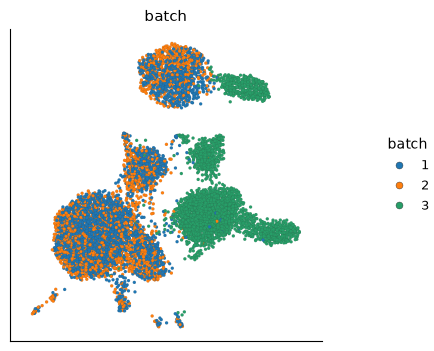

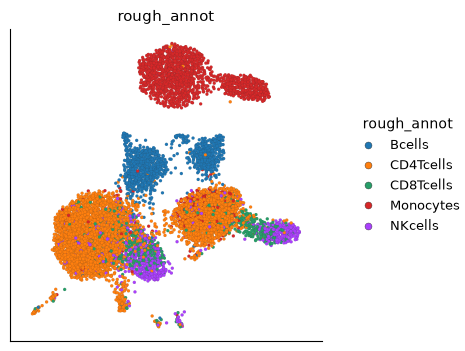

In [12]:
# Inspect batch separation before correction.
ds.plots.embedding(run=uncorrected, color_by="batch")
# Inspect cell-type structure before correction.
ds.plots.embedding(run=uncorrected, color_by="rough_annot")

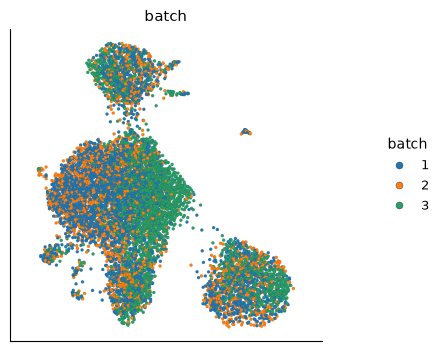

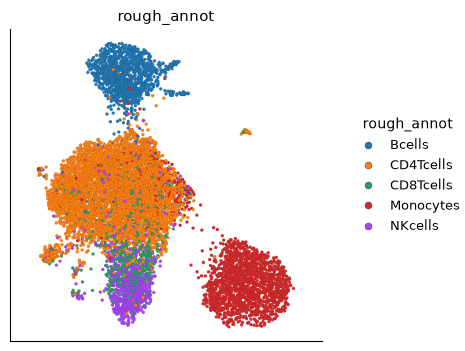

In [13]:
# Inspect batch mixing after Harmony correction.
ds.plots.embedding(run=harmony, color_by="batch")
# Check whether broad cell-type structure remains after correction.
ds.plots.embedding(run=harmony, color_by="rough_annot")

In [14]:
# Measure batch mixing and annotation preservation for one run.
def integration_diagnostics(run):
    return {
        "iLISI (batch)": ds.metric_ilisi(
            batch_colname="batch", neighbors=run["neighbors"]
        ),
        "cLISI (rough_annot)": ds.metric_clisi(
            annotation_column="rough_annot", neighbors=run["neighbors"]
        ),
        "graph connectivity (rough_annot)": ds.metric_graph_connectivity(
            annotation_column="rough_annot", graph=run["connectivity_map"]
        ),
    }

In [15]:
# Collect the mixing and preservation metrics for both runs.
score_frame = pd.DataFrame(
    {
        "Uncorrected": integration_diagnostics(uncorrected),
        "Harmony": integration_diagnostics(harmony),
    }
).T
# Compare mixing and preservation metrics for the two runs.
score_frame.round(3)

,iLISI (batch),cLISI (rough_annot),graph connectivity (rough_annot)
Uncorrected,0.062,0.997,0.949
Harmony,0.205,0.996,0.945
